# Imports

In [1]:
import json
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

import sys
import os

# Añade el directorio padre al sys.path
sys.path.append(os.path.abspath("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk"))

import hipy.hipy.pltext  as pltext

# Load Geometry 

In [2]:
# ─── 1. Load geometry ───
with open("/home/usc/ie/dcr/hk/ambe_analysis/AmBe_Data_Analysis/data/wcte_v11_20250513.json") as f:
    geo_data = json.load(f)

mpmt_data = geo_data["mpmts"]
N_PMTS = 2014

pmt_pos    = np.zeros((N_PMTS, 3))
pmt_normal = np.zeros((N_PMTS, 3))

for mpmt_idx in sorted(mpmt_data.keys(), key=int):
    mpmt = mpmt_data[mpmt_idx]
    for pmt_idx in sorted(mpmt["pmts"].keys(), key=int):
        pmt = mpmt["pmts"][pmt_idx]
        pmt_id = int(mpmt_idx) * 19 + int(pmt_idx)
        if pmt_id < N_PMTS:
            pmt_pos[pmt_id]    = pmt["placement"]["location"]
            pmt_normal[pmt_id] = pmt["placement"]["direction_z"]

# ─── 2. For each source position, compute cos(theta) and R per PMT ───
source_positions = {
    "R1767": np.array([0, 1525, 0]),
    "R1769": np.array([0, 476, 1175.8]),
    "R2336": np.array([0, -16.64, 562.8]),
    "R2337": np.array([-476.4, -28.1375, 291.7])
}

# Functions

In [3]:
def compute_angles(source_pos):
    """For each PMT, compute cos(theta) and distance R to source."""
    # Vector from source to PMT
    vec = pmt_pos - source_pos  # (N_PMTS, 3)
    R = np.linalg.norm(vec, axis=1)  # distance
    
    # Normalize
    vec_norm = vec / R[:, None]
    
    # cos(theta) = dot(source_to_pmt_normalized, pmt_normal)
    # Note: normal points outward, light comes inward, so we use -vec
    cos_theta = np.sum(-vec_norm * pmt_normal, axis=1)
    
    return cos_theta, R

# ─── 3. Load pure signal hits per PMT (from run_qe output or compute here) ───
def get_pure_hits(df_sig_path, df_bkg_path, trms_cut=2.0):
    df_sig = pd.read_parquet(df_sig_path)
    df_bkg = pd.read_parquet(df_bkg_path)
    
    if "trms" not in df_sig.columns:
        df_sig["trms"] = df_sig.groupby("candidate_id")["hit_pmt_calibrated_times"].transform("std")
    if "trms" not in df_bkg.columns:
        df_bkg["trms"] = df_bkg.groupby("candidate_id")["hit_pmt_calibrated_times"].transform("std")
    
    df_s = df_sig[df_sig["trms"] < trms_cut]
    df_b = df_bkg[df_bkg["trms"] < trms_cut]
    
    common = np.intersect1d(df_s["event_id"].unique(), df_b["event_id"].unique())
    df_s = df_s[df_s["event_id"].isin(common)]
    df_b = df_b[df_b["event_id"].isin(common)]
    
    hits_s = np.zeros(N_PMTS)
    hits_b = np.zeros(N_PMTS)
    
    for pmt_id, cnt in df_s.groupby("pmt_id").size().items():
        if 0 <= pmt_id < N_PMTS:
            hits_s[int(pmt_id)] = cnt
    for pmt_id, cnt in df_b.groupby("pmt_id").size().items():
        if 0 <= pmt_id < N_PMTS:
            hits_b[int(pmt_id)] = cnt
    
    pure = hits_s - hits_b
    pure[pure < 0] = 0
    n_cands = df_s["candidate_id"].nunique() - df_b["candidate_id"].nunique()
    return pure, max(n_cands, 1)

# Code

In [4]:
# ─── Example for Run 1767 ───
BASE = "/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude"
BKG = f"{BASE}/1767/data/df_bkg_R1766.parquet"

runs = {
    "R1767": f"{BASE}/1767/data/df_sig_R1767.parquet",
    "R1769": f"{BASE}/1769/data/df_sig_R1769.parquet",
    "R2336": f"{BASE}/2336/data/df_sig_R2336.parquet",
    "R2337": f"{BASE}/2337/data/df_sig_R2337.parquet"
}

# ─── 4. Load mPMT type info (detailed) ───
with open("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/raw_data/other_mpmt_info.dict", "rb") as f:
    mpmt_info = pickle.load(f)

pmt_category = np.full(N_PMTS, "Other", dtype=object)

for pmt_id in range(N_PMTS):
    slot = pmt_id // 19
    if slot in mpmt_info:
        mtype = mpmt_info[slot].get("mpmt_type", "")
        msite = mpmt_info[slot].get("mpmt_site", "")
        if msite == "TRI" and mtype == "In-situ":
            pmt_category[pmt_id] = "TRI In-situ"
        elif msite == "TRI" and mtype == "Ex-situ":
            pmt_category[pmt_id] = "TRI Ex-situ"
        elif msite == "WUT" and mtype == "In-situ":
            pmt_category[pmt_id] = "WUT In-situ"
        elif msite == "WUT" and mtype == "Ex-situ":
            pmt_category[pmt_id] = "WUT Ex-situ"

# Keep is_insitu for backward compatibility
is_insitu = np.array([c in ["TRI In-situ", "WUT In-situ"] for c in pmt_category])

category_colors = {
    "TRI In-situ": "blue",
    "TRI Ex-situ": "green",
    "WUT In-situ": "red",
    "WUT Ex-situ": "orange",
}

# 1767

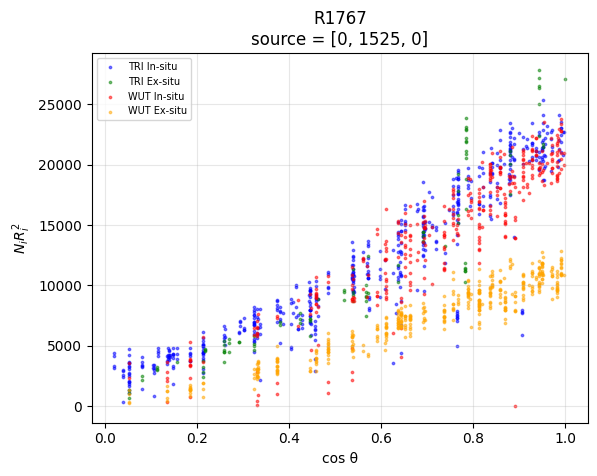

In [5]:
source = source_positions["R1767"]
cos_theta, R = compute_angles(source)
pure_hits, n_cands = get_pure_hits(runs["R1767"], BKG, trms_cut=2.0)

# Normalize hits per candidate
N_i = pure_hits / n_cands

# A(theta) proxy = N_i * R_i^2
A_theta = N_i * R**2

valid = (N_i > 0) & (cos_theta > 0)  # only PMTs facing the source

for cat, color in category_colors.items():
        mask = valid & (pmt_category == cat)
        if mask.sum() > 0:
            plt.scatter(cos_theta[mask], A_theta[mask],
                       s=3, alpha=0.5, color=color, label=cat)
    
plt.xlabel("cos θ")
plt.ylabel("$N_i R_i^2$")
plt.title(f"{'R1767'}\nsource = {source.tolist()}")
plt.legend(fontsize=7); 
plt.grid(alpha=0.3);

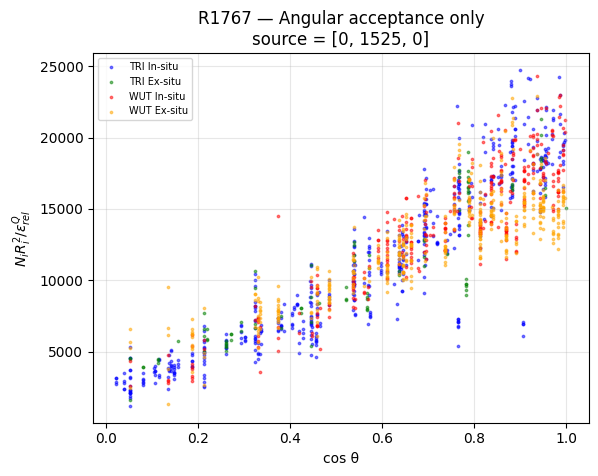

In [7]:
# ─── 10. Angular acceptance: N_i R_i^2 / RQE_i ───
# Divide by relative QE to cancel per-PMT QE variations and isolate A(θ)
run_label = "R1767"
mc_files  = "/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/1767/data/relative_qe.parquet"

source = source_positions[run_label]
cos_theta, R = compute_angles(source)
pure_hits, n_cands = get_pure_hits(runs["R1767"], BKG, trms_cut=2.0)
N_i = pure_hits / n_cands

# Load RQE for this run
qe_df = pd.read_parquet(mc_files)
rqe = qe_df["relative_qe"].values

# N_i * R^2 / RQE — should isolate angular acceptance
A_theta_clean = np.zeros(N_PMTS)
valid_rqe = rqe > 0
A_theta_clean[valid_rqe] = (N_i[valid_rqe] * R[valid_rqe]**2) / rqe[valid_rqe]

valid = (N_i > 0) & (cos_theta > 0) & valid_rqe

for cat, color in category_colors.items():
    mask = valid & (pmt_category == cat)
    if mask.sum() > 0:
        plt.scatter(cos_theta[mask], A_theta_clean[mask],
                    s=3, alpha=0.5, color=color, label=cat)

plt.xlabel("cos θ")
plt.ylabel("$N_i R_i^2 / \\epsilon^Q_{rel}$")
plt.title(f"{run_label} — Angular acceptance only\nsource = {source.tolist()}")
plt.legend(fontsize=7); 
plt.grid(alpha=0.3)

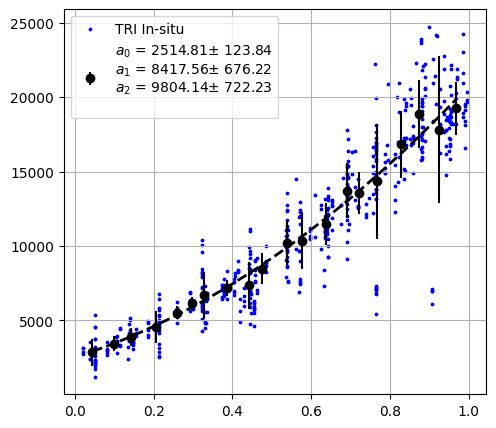

In [39]:
cat = "TRI In-situ"
valid = (N_i > 0) & (cos_theta > 0) & valid_rqe
mask = valid & (pmt_category == cat)

subplot = pltext.canvas(2)

subplot(1)
plt.scatter(cos_theta[mask], A_theta_clean[mask], s=3, alpha=1, color=category_colors[cat], label=cat);
pltext.hfitprofile(cos_theta[mask], A_theta_clean[mask], 
                   bins=20, 
                   fun='poly.2', 
                   std=True, 
                   color="k",
                   funopts={
                       "color": "k",      # mismo color que scatter
                        "linestyle": "--",   # dashed
                        "linewidth": 2
                        }
    );

# 1769

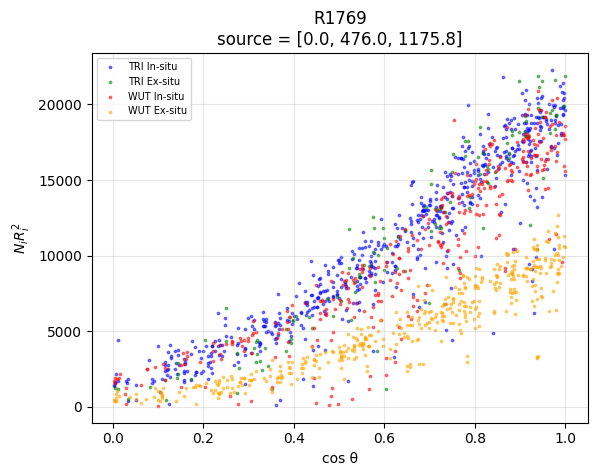

In [40]:
source = source_positions["R1769"]
cos_theta, R = compute_angles(source)
pure_hits, n_cands = get_pure_hits(runs["R1769"], BKG, trms_cut=2.0)

# Normalize hits per candidate
N_i = pure_hits / n_cands

# A(theta) proxy = N_i * R_i^2
A_theta = N_i * R**2

valid = (N_i > 0) & (cos_theta > 0)  # only PMTs facing the source

for cat, color in category_colors.items():
        mask = valid & (pmt_category == cat)
        if mask.sum() > 0:
            plt.scatter(cos_theta[mask], A_theta[mask],
                       s=3, alpha=0.5, color=color, label=cat)
    
plt.xlabel("cos θ")
plt.ylabel("$N_i R_i^2$")
plt.title(f"{'R1769'}\nsource = {source.tolist()}")
plt.legend(fontsize=7); 
plt.grid(alpha=0.3);

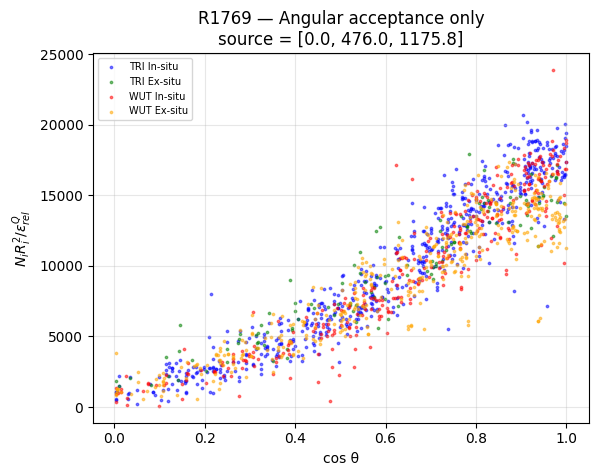

In [42]:
# ─── 10. Angular acceptance: N_i R_i^2 / RQE_i ───
# Divide by relative QE to cancel per-PMT QE variations and isolate A(θ)
run_label = "R1769"
mc_files  = "/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/1769/data/relative_qe.parquet"

source = source_positions[run_label]
cos_theta, R = compute_angles(source)
pure_hits, n_cands = get_pure_hits(runs["R1769"], BKG, trms_cut=2.0)
N_i = pure_hits / n_cands

# Load RQE for this run
qe_df = pd.read_parquet(mc_files)
rqe = qe_df["relative_qe"].values

# N_i * R^2 / RQE — should isolate angular acceptance
A_theta_clean = np.zeros(N_PMTS)
valid_rqe = rqe > 0
A_theta_clean[valid_rqe] = (N_i[valid_rqe] * R[valid_rqe]**2) / rqe[valid_rqe]

valid = (N_i > 0) & (cos_theta > 0) & valid_rqe

for cat, color in category_colors.items():
    mask = valid & (pmt_category == cat)
    if mask.sum() > 0:
        plt.scatter(cos_theta[mask], A_theta_clean[mask],
                    s=3, alpha=0.5, color=color, label=cat)

plt.xlabel("cos θ")
plt.ylabel("$N_i R_i^2 / \\epsilon^Q_{rel}$")
plt.title(f"{run_label} — Angular acceptance only\nsource = {source.tolist()}")
plt.legend(fontsize=7); 
plt.grid(alpha=0.3)

/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/software/python_envs/py39_venv/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:968: RuntimeWarning: divide by zero encountered in divide
  transform = 1.0 / sigma
/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/hipy/hipy/cfit.py:91: OptimizeWarning: Covariance of the parameters could not be estimated
  pars, fcov = optimize.curve_fit(cfun, x, y, p0 = cp0, sigma = sigma,


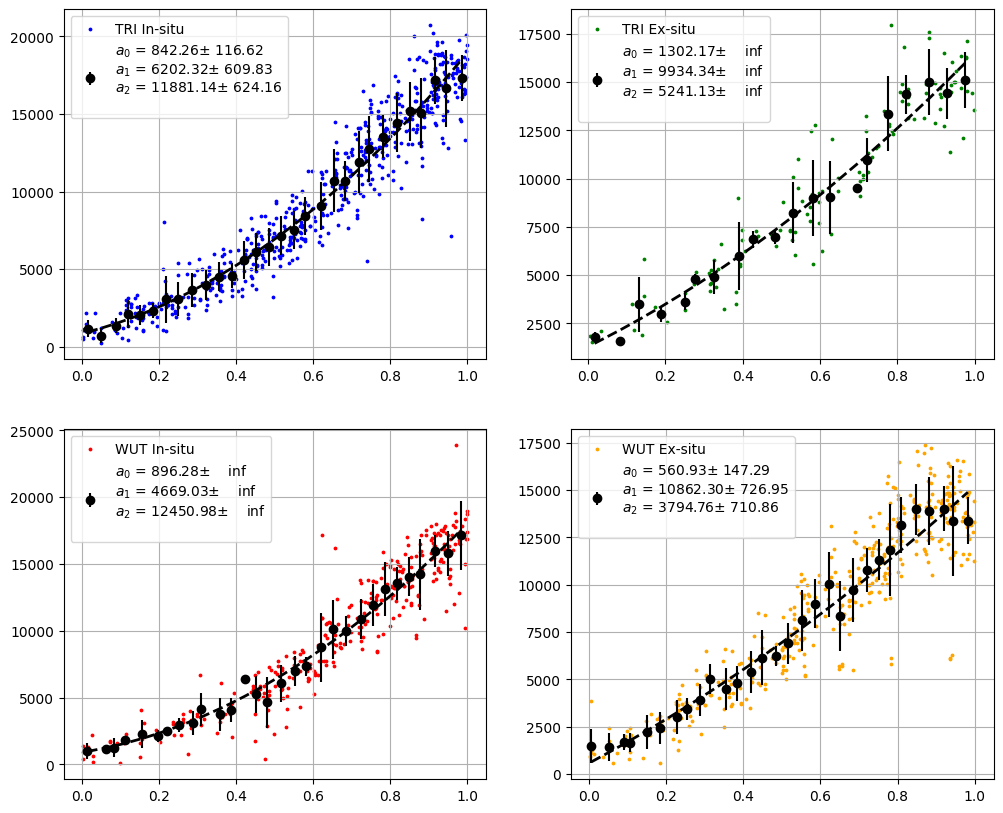

In [46]:
subplot = pltext.canvas(4)

subplot(1)
cat = "TRI In-situ"
valid = (N_i > 0) & (cos_theta > 0) & valid_rqe
mask = valid & (pmt_category == cat)

plt.scatter(cos_theta[mask], A_theta_clean[mask], s=3, alpha=1, color=category_colors[cat], label=cat);
pltext.hfitprofile(cos_theta[mask], A_theta_clean[mask], 
                   bins=30, 
                   fun='poly.2', 
                   std=True, 
                   color="k",
                   funopts={
                       "color": "k",      # mismo color que scatter
                        "linestyle": "--",   # dashed
                        "linewidth": 2
                        }
    );

subplot(2)
cat = "TRI Ex-situ"
valid = (N_i > 0) & (cos_theta > 0) & valid_rqe
mask = valid & (pmt_category == cat)

plt.scatter(cos_theta[mask], A_theta_clean[mask], s=3, alpha=1, color=category_colors[cat], label=cat);
pltext.hfitprofile(cos_theta[mask], A_theta_clean[mask], 
                   bins=20, 
                   fun='poly.2', 
                   std=True, 
                   color="k",
                   funopts={
                       "color": "k",      # mismo color que scatter
                        "linestyle": "--",   # dashed
                        "linewidth": 2
                        }
    );

subplot(3)
cat = "WUT In-situ"
valid = (N_i > 0) & (cos_theta > 0) & valid_rqe
mask = valid & (pmt_category == cat)

plt.scatter(cos_theta[mask], A_theta_clean[mask], s=3, alpha=1, color=category_colors[cat], label=cat);
pltext.hfitprofile(cos_theta[mask], A_theta_clean[mask], 
                   bins=30, 
                   fun='poly.2', 
                   std=True, 
                   color="k",
                   funopts={
                       "color": "k",      # mismo color que scatter
                        "linestyle": "--",   # dashed
                        "linewidth": 2
                        }
    );

subplot(4)
cat = "WUT Ex-situ"
valid = (N_i > 0) & (cos_theta > 0) & valid_rqe
mask = valid & (pmt_category == cat)

plt.scatter(cos_theta[mask], A_theta_clean[mask], s=3, alpha=1, color=category_colors[cat], label=cat);
pltext.hfitprofile(cos_theta[mask], A_theta_clean[mask], 
                   bins=30, 
                   fun='poly.2', 
                   std=True, 
                   color="k",
                   funopts={
                       "color": "k",      # mismo color que scatter
                        "linestyle": "--",   # dashed
                        "linewidth": 2
                        }
    );


# 2336

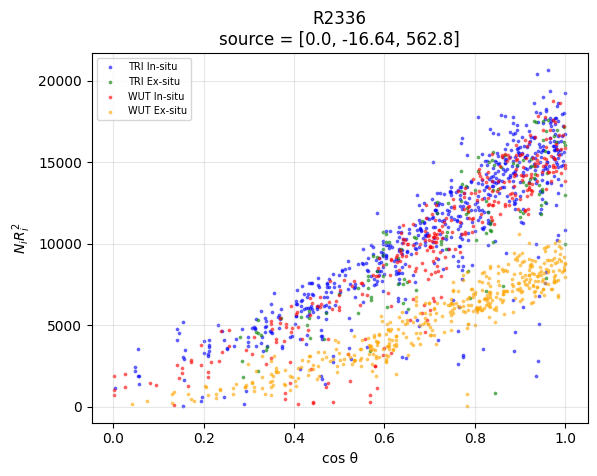

In [47]:
source = source_positions["R2336"]
cos_theta, R = compute_angles(source)
pure_hits, n_cands = get_pure_hits(runs["R2336"], BKG, trms_cut=2.0)

# Normalize hits per candidate
N_i = pure_hits / n_cands

# A(theta) proxy = N_i * R_i^2
A_theta = N_i * R**2

valid = (N_i > 0) & (cos_theta > 0)  # only PMTs facing the source

for cat, color in category_colors.items():
        mask = valid & (pmt_category == cat)
        if mask.sum() > 0:
            plt.scatter(cos_theta[mask], A_theta[mask],
                       s=3, alpha=0.5, color=color, label=cat)
    
plt.xlabel("cos θ")
plt.ylabel("$N_i R_i^2$")
plt.title(f"{'R2336'}\nsource = {source.tolist()}")
plt.legend(fontsize=7); 
plt.grid(alpha=0.3);

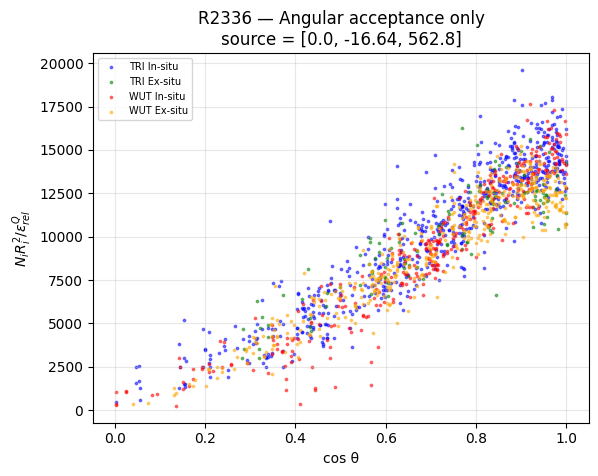

In [48]:
# ─── 10. Angular acceptance: N_i R_i^2 / RQE_i ───
# Divide by relative QE to cancel per-PMT QE variations and isolate A(θ)
run_label = "R2336"
mc_files  = "/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/2336/data/relative_qe.parquet"

source = source_positions[run_label]
cos_theta, R = compute_angles(source)
pure_hits, n_cands = get_pure_hits(runs["R2336"], BKG, trms_cut=2.0)
N_i = pure_hits / n_cands

# Load RQE for this run
qe_df = pd.read_parquet(mc_files)
rqe = qe_df["relative_qe"].values

# N_i * R^2 / RQE — should isolate angular acceptance
A_theta_clean = np.zeros(N_PMTS)
valid_rqe = rqe > 0
A_theta_clean[valid_rqe] = (N_i[valid_rqe] * R[valid_rqe]**2) / rqe[valid_rqe]

valid = (N_i > 0) & (cos_theta > 0) & valid_rqe

for cat, color in category_colors.items():
    mask = valid & (pmt_category == cat)
    if mask.sum() > 0:
        plt.scatter(cos_theta[mask], A_theta_clean[mask],
                    s=3, alpha=0.5, color=color, label=cat)

plt.xlabel("cos θ")
plt.ylabel("$N_i R_i^2 / \\epsilon^Q_{rel}$")
plt.title(f"{run_label} — Angular acceptance only\nsource = {source.tolist()}")
plt.legend(fontsize=7); 
plt.grid(alpha=0.3)

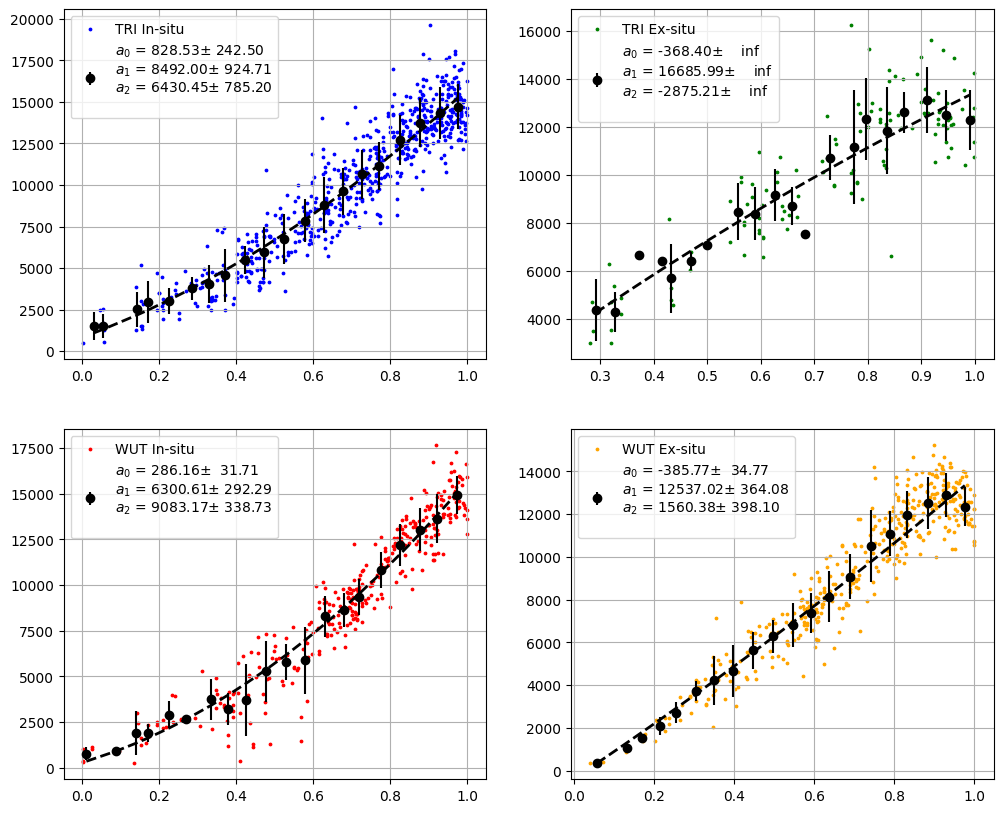

In [51]:
subplot = pltext.canvas(4)

subplot(1)
cat = "TRI In-situ"
valid = (N_i > 0) & (cos_theta > 0) & valid_rqe
mask = valid & (pmt_category == cat)

plt.scatter(cos_theta[mask], A_theta_clean[mask], s=3, alpha=1, color=category_colors[cat], label=cat);
pltext.hfitprofile(cos_theta[mask], A_theta_clean[mask], 
                   bins=20, 
                   fun='poly.2', 
                   std=True, 
                   color="k",
                   funopts={
                       "color": "k",      # mismo color que scatter
                        "linestyle": "--",   # dashed
                        "linewidth": 2
                        }
    );

subplot(2)
cat = "TRI Ex-situ"
valid = (N_i > 0) & (cos_theta > 0) & valid_rqe
mask = valid & (pmt_category == cat)

plt.scatter(cos_theta[mask], A_theta_clean[mask], s=3, alpha=1, color=category_colors[cat], label=cat);
pltext.hfitprofile(cos_theta[mask], A_theta_clean[mask], 
                   bins=20, 
                   fun='poly.2', 
                   std=True, 
                   color="k",
                   funopts={
                       "color": "k",      # mismo color que scatter
                        "linestyle": "--",   # dashed
                        "linewidth": 2
                        }
    );

subplot(3)
cat = "WUT In-situ"
valid = (N_i > 0) & (cos_theta > 0) & valid_rqe
mask = valid & (pmt_category == cat)

plt.scatter(cos_theta[mask], A_theta_clean[mask], s=3, alpha=1, color=category_colors[cat], label=cat);
pltext.hfitprofile(cos_theta[mask], A_theta_clean[mask], 
                   bins=20, 
                   fun='poly.2', 
                   std=True, 
                   color="k",
                   funopts={
                       "color": "k",      # mismo color que scatter
                        "linestyle": "--",   # dashed
                        "linewidth": 2
                        }
    );

subplot(4)
cat = "WUT Ex-situ"
valid = (N_i > 0) & (cos_theta > 0) & valid_rqe
mask = valid & (pmt_category == cat)

plt.scatter(cos_theta[mask], A_theta_clean[mask], s=3, alpha=1, color=category_colors[cat], label=cat);
pltext.hfitprofile(cos_theta[mask], A_theta_clean[mask], 
                   bins=20, 
                   fun='poly.2', 
                   std=True, 
                   color="k",
                   funopts={
                       "color": "k",      # mismo color que scatter
                        "linestyle": "--",   # dashed
                        "linewidth": 2
                        }
    );


# 2337

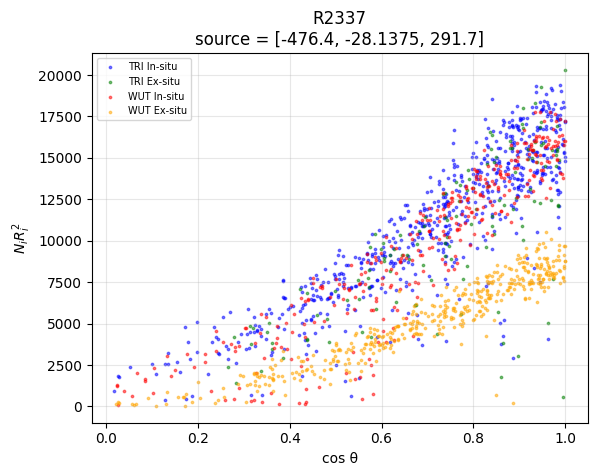

In [52]:
source = source_positions["R2337"]
cos_theta, R = compute_angles(source)
pure_hits, n_cands = get_pure_hits(runs["R2337"], BKG, trms_cut=2.0)

# Normalize hits per candidate
N_i = pure_hits / n_cands

# A(theta) proxy = N_i * R_i^2
A_theta = N_i * R**2

valid = (N_i > 0) & (cos_theta > 0)  # only PMTs facing the source

for cat, color in category_colors.items():
        mask = valid & (pmt_category == cat)
        if mask.sum() > 0:
            plt.scatter(cos_theta[mask], A_theta[mask],
                       s=3, alpha=0.5, color=color, label=cat)
    
plt.xlabel("cos θ")
plt.ylabel("$N_i R_i^2$")
plt.title(f"{'R2337'}\nsource = {source.tolist()}")
plt.legend(fontsize=7);
plt.grid(alpha=0.3);

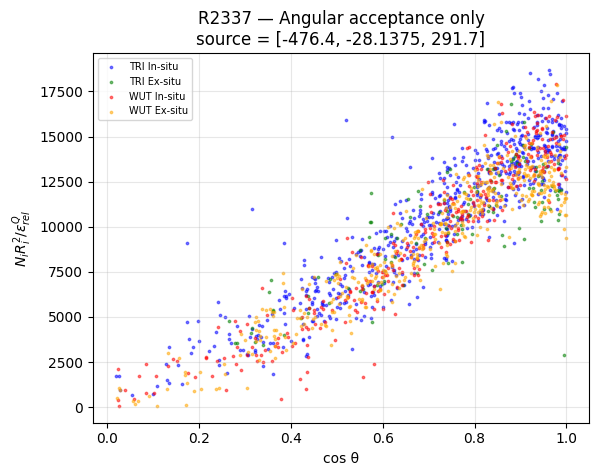

In [53]:
# ─── 10. Angular acceptance: N_i R_i^2 / RQE_i ───
# Divide by relative QE to cancel per-PMT QE variations and isolate A(θ)
run_label = "R2337"
mc_files  = "/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/2337/data/relative_qe.parquet"

source = source_positions[run_label]
cos_theta, R = compute_angles(source)
pure_hits, n_cands = get_pure_hits(runs["R2337"], BKG, trms_cut=2.0)
N_i = pure_hits / n_cands

# Load RQE for this run
qe_df = pd.read_parquet(mc_files)
rqe = qe_df["relative_qe"].values

# N_i * R^2 / RQE — should isolate angular acceptance
A_theta_clean = np.zeros(N_PMTS)
valid_rqe = rqe > 0
A_theta_clean[valid_rqe] = (N_i[valid_rqe] * R[valid_rqe]**2) / rqe[valid_rqe]

valid = (N_i > 0) & (cos_theta > 0) & valid_rqe

for cat, color in category_colors.items():
    mask = valid & (pmt_category == cat)
    if mask.sum() > 0:
        plt.scatter(cos_theta[mask], A_theta_clean[mask],
                    s=3, alpha=0.5, color=color, label=cat)

plt.xlabel("cos θ")
plt.ylabel("$N_i R_i^2 / \\epsilon^Q_{rel}$")
plt.title(f"{run_label} — Angular acceptance only\nsource = {source.tolist()}")
plt.legend(fontsize=7); 
plt.grid(alpha=0.3)

/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/software/python_envs/py39_venv/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:968: RuntimeWarning: divide by zero encountered in divide
  transform = 1.0 / sigma
/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/hipy/hipy/cfit.py:91: OptimizeWarning: Covariance of the parameters could not be estimated
  pars, fcov = optimize.curve_fit(cfun, x, y, p0 = cp0, sigma = sigma,


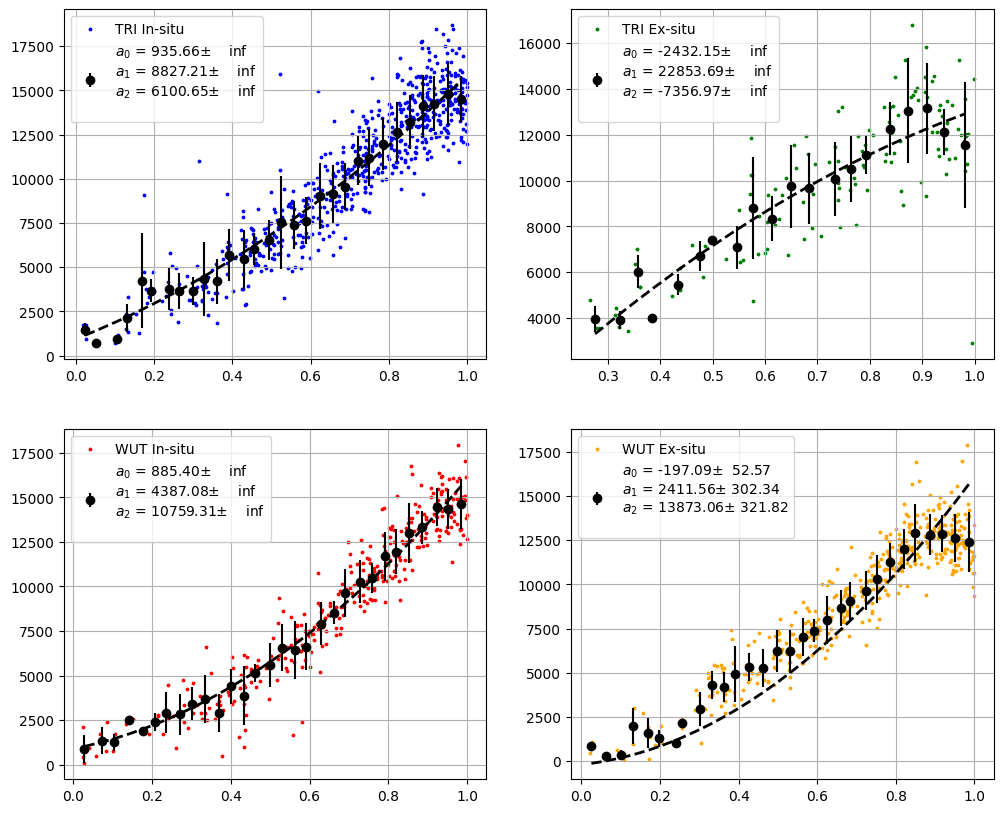

In [54]:
subplot = pltext.canvas(4)

subplot(1)
cat = "TRI In-situ"
valid = (N_i > 0) & (cos_theta > 0) & valid_rqe
mask = valid & (pmt_category == cat)

plt.scatter(cos_theta[mask], A_theta_clean[mask], s=3, alpha=1, color=category_colors[cat], label=cat);
pltext.hfitprofile(cos_theta[mask], A_theta_clean[mask], 
                   bins=30, 
                   fun='poly.2', 
                   std=True, 
                   color="k",
                   funopts={
                       "color": "k",      # mismo color que scatter
                        "linestyle": "--",   # dashed
                        "linewidth": 2
                        }
    );

subplot(2)
cat = "TRI Ex-situ"
valid = (N_i > 0) & (cos_theta > 0) & valid_rqe
mask = valid & (pmt_category == cat)

plt.scatter(cos_theta[mask], A_theta_clean[mask], s=3, alpha=1, color=category_colors[cat], label=cat);
pltext.hfitprofile(cos_theta[mask], A_theta_clean[mask], 
                   bins=20, 
                   fun='poly.2', 
                   std=True, 
                   color="k",
                   funopts={
                       "color": "k",      # mismo color que scatter
                        "linestyle": "--",   # dashed
                        "linewidth": 2
                        }
    );

subplot(3)
cat = "WUT In-situ"
valid = (N_i > 0) & (cos_theta > 0) & valid_rqe
mask = valid & (pmt_category == cat)

plt.scatter(cos_theta[mask], A_theta_clean[mask], s=3, alpha=1, color=category_colors[cat], label=cat);
pltext.hfitprofile(cos_theta[mask], A_theta_clean[mask], 
                   bins=30, 
                   fun='poly.2', 
                   std=True, 
                   color="k",
                   funopts={
                       "color": "k",      # mismo color que scatter
                        "linestyle": "--",   # dashed
                        "linewidth": 2
                        }
    );

subplot(4)
cat = "WUT Ex-situ"
valid = (N_i > 0) & (cos_theta > 0) & valid_rqe
mask = valid & (pmt_category == cat)

plt.scatter(cos_theta[mask], A_theta_clean[mask], s=3, alpha=1, color=category_colors[cat], label=cat);
pltext.hfitprofile(cos_theta[mask], A_theta_clean[mask], 
                   bins=30, 
                   fun='poly.2', 
                   std=True, 
                   color="k",
                   funopts={
                       "color": "k",      # mismo color que scatter
                        "linestyle": "--",   # dashed
                        "linewidth": 2
                        }
    );
